In [1]:
import numpy as np
import pandas as pd

train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')

In [2]:
train_df.info(), train_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


(None, (40000, 12))

In [3]:
train_df.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


In [4]:
test_df.info(), test_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10000 non-null  int64  
 1   airline      9452 non-null   object 
 2   flight       10000 non-null  object 
 3   source       10000 non-null  object 
 4   departure    9080 non-null   object 
 5   stops        9349 non-null   object 
 6   arrival      10000 non-null  object 
 7   destination  10000 non-null  object 
 8   class        10000 non-null  object 
 9   duration     9418 non-null   float64
 10  days_left    9304 non-null   float64
dtypes: float64(2), int64(1), object(8)
memory usage: 859.5+ KB


(None, (10000, 11))

In [5]:
test_df.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0


In [6]:
train_df.describe()

,id,duration,days_left,price
count,40000.00000,36987.000000,35562.000000,40000.00000
mean,19999.50000,12.004088,26.197936,20801.49025
std,11547.14972,7.108063,13.469232,22729.14842
min,0.00000,0.830000,1.000000,1105.00000
25%,9999.75000,6.670000,15.000000,4687.00000
50%,19999.50000,11.080000,26.000000,7353.00000
75%,29999.25000,15.920000,38.000000,42521.00000
max,39999.00000,47.080000,49.000000,114704.00000


In [7]:
test_df.describe()

,id,duration,days_left
count,10000.00000,9418.000000,9304.000000
mean,4999.50000,12.005125,26.163156
std,2886.89568,7.086652,13.453717
min,0.00000,0.920000,1.000000
25%,2499.75000,6.670000,15.000000
50%,4999.50000,11.170000,26.000000
75%,7499.25000,15.920000,38.000000
max,9999.00000,40.420000,49.000000


In [8]:
train_df.isna().sum()

,0
id,0
airline,4613
flight,0
source,0
departure,4792
stops,2319
arrival,0
destination,0
class,0
duration,3013


In [9]:
round((train_df.isnull().sum()/train_df.shape[0])*100,2)

,0
id,0.00
airline,11.53
flight,0.00
source,0.00
departure,11.98
stops,5.80
arrival,0.00
destination,0.00
class,0.00
duration,7.53


In [10]:
test_df.isna().sum()

,0
id,0
airline,548
flight,0
source,0
departure,920
stops,651
arrival,0
destination,0
class,0
duration,582


In [11]:
round((test_df.isnull().sum()/test_df.shape[0])*100,2)

,0
id,0.00
airline,5.48
flight,0.00
source,0.00
departure,9.20
stops,6.51
arrival,0.00
destination,0.00
class,0.00
duration,5.82


In [12]:
CatVar = [col for col in train_df.columns if train_df[col].dtype == 'object']
print('Categorical columns :',CatVar)

NumVar = [col for col in train_df.columns if train_df[col].dtype == 'float64']
print('Numerical columns :',NumVar)

Categorical columns : ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']
Numerical columns : ['duration', 'days_left']


In [13]:
from sklearn.impute import KNNImputer, SimpleImputer

imputer = SimpleImputer(strategy = 'most_frequent')
train_df[CatVar] = imputer.fit_transform(train_df[CatVar])
test_df[CatVar] = imputer.fit_transform(test_df[CatVar])

train_df[CatVar].info()
print()
print(test_df[CatVar].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   airline      40000 non-null  object
 1   flight       40000 non-null  object
 2   source       40000 non-null  object
 3   departure    40000 non-null  object
 4   stops        40000 non-null  object
 5   arrival      40000 non-null  object
 6   destination  40000 non-null  object
 7   class        40000 non-null  object
dtypes: object(8)
memory usage: 2.4+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   airline      10000 non-null  object
 1   flight       10000 non-null  object
 2   source       10000 non-null  object
 3   departure    10000 non-null  object
 4   stops        10000 non-null  object
 5   arrival      10000 non-null  object
 6   d

In [14]:
knnimputer = KNNImputer(n_neighbors=5)
train_df[NumVar] = knnimputer.fit_transform(train_df[NumVar])
test_df[NumVar] = knnimputer.fit_transform(test_df[NumVar])

CombNumCols = pd.concat((train_df[NumVar], test_df[NumVar]), axis=1)
CombNumCols.corr()

,duration,days_left,duration,days_left
duration,1.000000,-0.045797,0.002175,0.011642
days_left,-0.045797,1.000000,-0.011348,-0.001744
duration,0.002175,-0.011348,1.000000,-0.030951
days_left,0.011642,-0.001744,-0.030951,1.000000


In [15]:
print("TRAIN DATASET AFTER IMPUTING THE MISSING VALUES:")
print(train_df.info())
print()
print()

print("TEST DATASET AFTER IMPUTING THE MISSING VALUES:")
print(test_df.info())

TRAIN DATASET AFTER IMPUTING THE MISSING VALUES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      40000 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    40000 non-null  object 
 5   stops        40000 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     40000 non-null  float64
 10  days_left    40000 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB
None


TEST DATASET AFTER IMPUTING THE MISSING VALUES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Co

In [16]:
print("Duplicates in train data: ",train_df.duplicated().sum())
print("Duplicates in test data: ",test_df.duplicated().sum())

Duplicates in train data:  0
Duplicates in test data:  0


In [17]:
num_cols = train_df.select_dtypes(include=np.number).columns
num_cols

Index(['id', 'duration', 'days_left', 'price'], dtype='object')

In [18]:
def outlier_n_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lowerbound = Q1 - 1.5 * IQR
    upperbound = Q3 + 1.5 * IQR
    return df[(df[col] < lowerbound) | (df[col] > upperbound)].index

price_outlier_index = outlier_n_iqr(train_df, "price")
duration_outlier_index = outlier_n_iqr(train_df, "duration")

print(f"price: {len(price_outlier_index)} outliers")
print(f"duration: {len(duration_outlier_index)} outliers")

price: 14 outliers
duration: 292 outliers


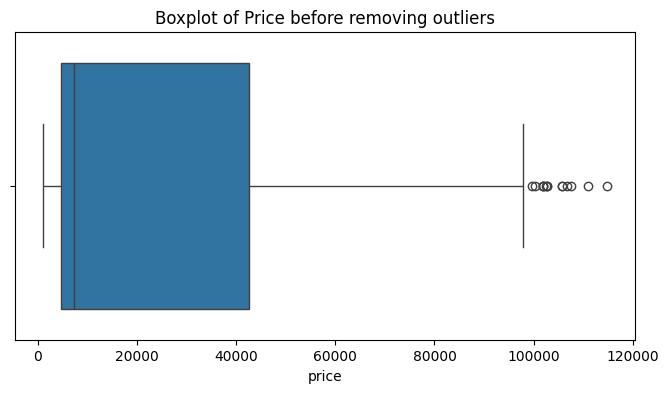

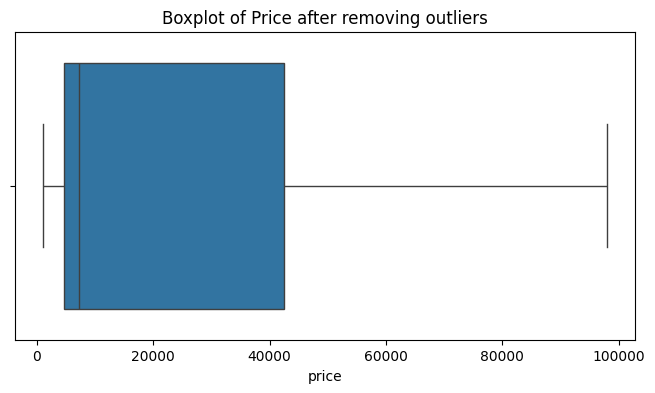

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 4))
sns.boxplot(x = train_df['price'])
plt.title("Boxplot of Price before removing outliers")
plt.show()

train_df = train_df.drop(price_outlier_index) #removing the outliers

plt.figure(figsize = (8, 4))
sns.boxplot(x = train_df['price'])
plt.title("Boxplot of Price after removing outliers")
plt.show()

**Retaining the outliers in the 'duration' column:** While it has significantly high number of outliers, it does not really affect the model of the data since our target variable is price.

**Elimination of 'price' outliers:** Even though it has a low number of outliers as compared to 'duration' dataset, it can significantly affect the model of the data and skew the results. Hence, it was important that we dropped the outliers from the target variable 'price'.

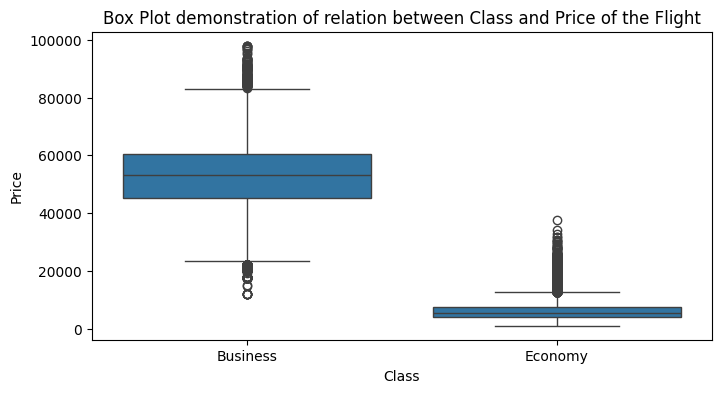

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x='class', y='price')
plt.title('Box Plot demonstration of relation between Class and Price of the Flight') #effect of Class on Ticket Prices
plt.xlabel('Class')
plt.ylabel('Price')
plt.show()

**Inference from the Plot**

The box plot depicts that the business classes have significantly higher flight fares and also a wider variability of prices in contrast to the economy classes, which are more concentrated and have lower prices. This insight that flight class is a strong and influential factor in determining ticket prices.

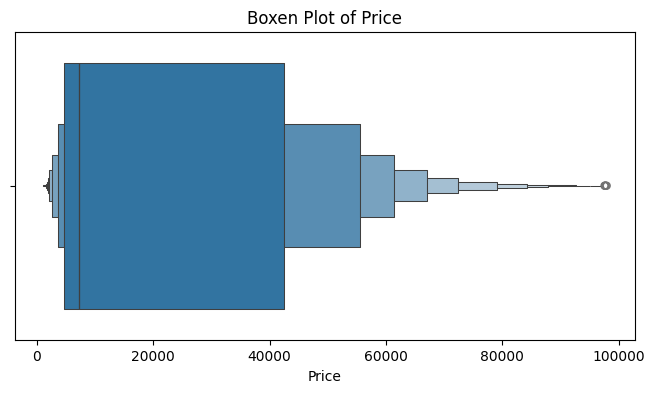

In [21]:
plt.figure(figsize=(8, 4))
sns.boxenplot(data=train_df, x='price')
plt.title('Boxen Plot of Price') #effect of Class on Ticket Prices
plt.xlabel('Price')
plt.show()

**Inference from the plot**

Right-skewed data shows that the cheap economy seats are common whereas high-end or last-minute fares are rare but pricey. The plot also suggests that the algorithm sensitive to scale will be influenced by the long tail, as tree-based models are more robust, considering a log-transform or regression for capping tasks.

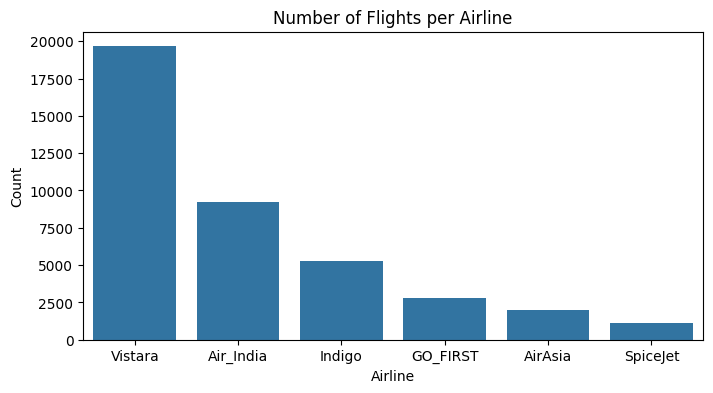

In [22]:
plt.figure(figsize=(8, 4))
sns.countplot(data=train_df, x='airline', order=train_df['airline'].value_counts().index)
plt.title('Number of Flights per Airline')
plt.xlabel('Airline')
plt.ylabel('Count')
plt.show()

**Inference from the Plot**

The plot depicts Vistara as the operator of the highest number of flights per airline, which suggests its dominating presence in the airline market among its other competitors such as Air India, Indigo and others. SpiceJet ranks with the lowest numbers of flights per airline in the data. Disparities as such can impact model training, specifically when dealing with categorical features like 'Airline'.

In [23]:
CatVar = [col for col in train_df.columns if train_df[col].dtype == 'object']
print('Categorical columns :',CatVar)

NumVar = [col for col in train_df.columns if train_df[col].dtype != 'object']
print('Numerical columns :',NumVar)

Categorical columns : ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']
Numerical columns : ['id', 'duration', 'days_left', 'price']


In [24]:
CatVarToEncode = ['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']

EncodedTrain = pd.get_dummies(train_df, columns=CatVarToEncode)
EncodedTest = pd.get_dummies(test_df, columns=CatVarToEncode)

EncodedTest = EncodedTest.reindex(columns=EncodedTrain.columns.drop('price'), fill_value=0)



#scaling numerical features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
NumCols = ['duration', 'days_left']
EncodedTrain[NumCols] = scaler.fit_transform(EncodedTrain[NumCols])
EncodedTest[NumCols] = scaler.fit_transform(EncodedTest[NumCols])

In [25]:
from sklearn.model_selection import train_test_split
X = EncodedTrain.drop(['price', 'id'], axis=1)
y = EncodedTrain['price']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    rmse = root_mean_squared_error(y_val, preds)
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)

    results.append((name, rmse, mae, r2))

results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'MAE', 'R² Score'])
results_df = results_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

display(results_df)

,Model,RMSE,MAE,R² Score
0,Random Forest,3549.804706,1778.875521,0.975452
1,Decision Tree,4334.538026,1918.202446,0.963400
2,Gradient Boosting,5177.049502,3132.229943,0.947789
3,KNN Regressor,5643.312906,3387.540160,0.937960
4,Ridge Regression,6411.448348,4459.850910,0.919922
5,Linear Regression,6422.546241,4475.152326,0.919644
6,Lasso Regression,6446.828891,4448.125189,0.919036


In [30]:
from sklearn.model_selection import GridSearchCV
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge = Ridge()
grid_ridge = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_root_mean_squared_error')
grid_ridge.fit(X_train, y_train)

print("Best Ridge RMSE:", -grid_ridge.best_score_)
print("Best Ridge Parameters:", grid_ridge.best_params_)

Best Ridge RMSE: 6310.544416687137
Best Ridge Parameters: {'alpha': 1}


In [38]:
from sklearn.linear_model import Lasso

lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

lasso = Lasso(max_iter=5000)

grid_lasso = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_root_mean_squared_error')
grid_lasso.fit(X_train, y_train)

print("Best Lasso RMSE:", -grid_lasso.best_score_)
print("Best Lasso Parameters:", grid_lasso.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.347e+09, tolerance: 1.315e+09
  model = cd_fast.enet_coordinate_descent(


Best Lasso RMSE: 6313.890095930959
Best Lasso Parameters: {'alpha': 0.1}


In [39]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
rf_params = {
    'n_estimators': randint(20, 60),
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(n_jobs=-1)
rf_random = RandomizedSearchCV(
    rf, rf_params, n_iter=5, cv=2,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1
)
rf_random.fit(X_train, y_train)

print("Best RF RMSE:", -rf_random.best_score_)
print("Best RF Parameters:", rf_random.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best RF RMSE: 3774.4123155738885
Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 43}


1. RMSE: Penalizes larger errors more
2. MAE: Gives equal weight to all errors
3. R2 Score:How well predictions explain variability in price

In [40]:
SortedResults = results_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)
print(SortedResults)

               Model         RMSE          MAE  R² Score
0      Random Forest  3549.804706  1778.875521  0.975452
1      Decision Tree  4334.538026  1918.202446  0.963400
2  Gradient Boosting  5177.049502  3132.229943  0.947789
3      KNN Regressor  5643.312906  3387.540160  0.937960
4   Ridge Regression  6411.448348  4459.850910  0.919922
5  Linear Regression  6422.546241  4475.152326  0.919644
6   Lasso Regression  6446.828891  4448.125189  0.919036


In [41]:
final_model = RandomForestRegressor(
    n_estimators=48,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)
final_model.fit(X, y)

RandomForestRegressor(min_samples_split=5, n_estimators=48, random_state=42)

In [42]:
final_pred = final_model.predict(EncodedTest.drop('id', axis=1))
submission_df = pd.read_csv('/content/sample_submission.csv')
submission_df['price'] = final_pred.astype(int)
submission_df.to_csv('submission.csv', index=False)

submission_df

,id,price
0,0,4503
1,1,12280
2,2,4299
3,3,60053
4,4,50884
...,...,...
9995,9995,4345
9996,9996,6056
9997,9997,59654
9998,9998,56590
